## Random Forest Classifier

### Part 1

##### Importing necessary libraries and constant variables

In [ ]:
import os

# Clone the repo into Colab's working directory
!git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

# Add project root to Python path so 'src' is importable
import sys
sys.path.insert(0, '/content/ds207_final_project')

# Verify src exists
from pathlib import Path
src_path = Path('/content/ds207_final_project/src')
print(f"src exists: {src_path.exists()}")
print("src contents:")
for item in sorted(src_path.iterdir()):
    print(f"  {item.name}")

In [20]:


# custom imports
from src.utils.data_fetch import DataLoader
from src.visualisations.viz_model import plot_confusion_matrix

# sklearn libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# various scoring metrics
from sklearn.metrics import (classification_report,
                             recall_score, precision_score,
                             f1_score, roc_auc_score)

# for hyperparameter tuning
import optuna

SEED = 1234

##### Functions to be used for model creation, evaluation and visualization

In [21]:
def fit_random_forest(Xtrain, ytrain, Xval,
                      chosen_features_list=None,
                      seed=SEED,
                      n_estimators=100,
                      max_depth=None,
                      min_samples_split=2,
                      min_samples_leaf=1):
    """
    Fits a Random Forest classifier on the selected features from the training
    dataset and evaluates it on both the training and validation datasets.

    :param Xtrain: Training feature DataFrame.
    :param ytrain: Training target DataFrame (must contain 'readmitted' column).
    :param Xval: Validation feature DataFrame.
    :param chosen_features_list: List of feature names to use. Defaults to all features.
    :param seed: Random seed for reproducibility. Defaults to SEED.
    :param n_estimators: Number of trees in the forest.
    :param max_depth: Maximum depth of each tree. None = unlimited.
    :param min_samples_split: Minimum samples required to split a node.
    :param min_samples_leaf: Minimum samples required at a leaf node.
    :return: Tuple of (fitted model, train predictions, validation predictions).
    """
    if chosen_features_list is None:
        chosen_features_list = Xtrain.columns.to_list()

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )

    model.fit(Xtrain[chosen_features_list], ytrain['readmitted'])

    y_pred_train = model.predict(Xtrain[chosen_features_list])
    y_pred_val   = model.predict(Xval[chosen_features_list])

    return model, y_pred_train, y_pred_val

In [22]:
## -> added to src.utils.model_eval.evaluation
def evaluate_predictions(true_values, predictions, print_class_report=True):
    """
    Evaluate classification predictions using recall, precision, F1-score,
    and optionally prints the classification report.

    :param true_values: DataFrame containing the actual class labels ('readmitted' column).
    :param predictions: Predicted labels.
    :param print_class_report: Whether to print the classification report. Defaults to True.
    :return: Tuple of (recall, precision, f1, classification_report string).
    """
    recall = recall_score(y_true=true_values['readmitted'], y_pred=predictions)
    precision = precision_score(y_true=true_values['readmitted'], y_pred=predictions)
    f1 = f1_score(y_true=true_values['readmitted'], y_pred=predictions)
    cl_report = classification_report(
        y_true=true_values['readmitted'],
        y_pred=predictions,
        zero_division=0
    )
    if print_class_report:
        print(cl_report)
    return recall, precision, f1, cl_report

##### Loading the final processed data (one-hot encoded version)

In [23]:
df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest = \
    DataLoader().fetch_data(version='final_onehot')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


### Part 2 - Draft Model (Numeric Features Only)

Choosing numeric features for a draft Random Forest model:

In [27]:
chosen_features = [
    'pipeline_standard__time_in_hospital',
    'pipeline_standard__num_lab_procedures',
    'pipeline_standard__num_procedures',
    'pipeline_standard__num_medications',
    'pipeline_standard__number_outpatient',
    'pipeline_standard__number_emergency',
    'pipeline_standard__number_inpatient',
    'pipeline_standard__number_diagnoses'
]

Dropping identifier columns and fitting draft model:

In [28]:
# Drop identifier columns
id_cols = [c for c in df_Xtrain.columns if 'encounter_id' in c or 'patient_nbr' in c]
X_train_rf = df_Xtrain.drop(columns=id_cols)
X_val_rf   = df_Xval.drop(columns=id_cols)
X_test_rf  = df_Xtest.drop(columns=id_cols)

# Fit draft model (numeric features only)
rf_draft, y_pred_tr, y_pred_vl = fit_random_forest(
    Xtrain=X_train_rf,
    ytrain=df_ytrain,
    Xval=X_val_rf,
    chosen_features_list=chosen_features,
    seed=SEED
)
rf_draft

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=1234)

### Initial Classification Report: Training Set

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     31515
           1       0.97      0.97      0.97     28090

    accuracy                           0.97     59605
   macro avg       0.97      0.97      0.97     59605
weighted avg       0.97      0.97      0.97     59605



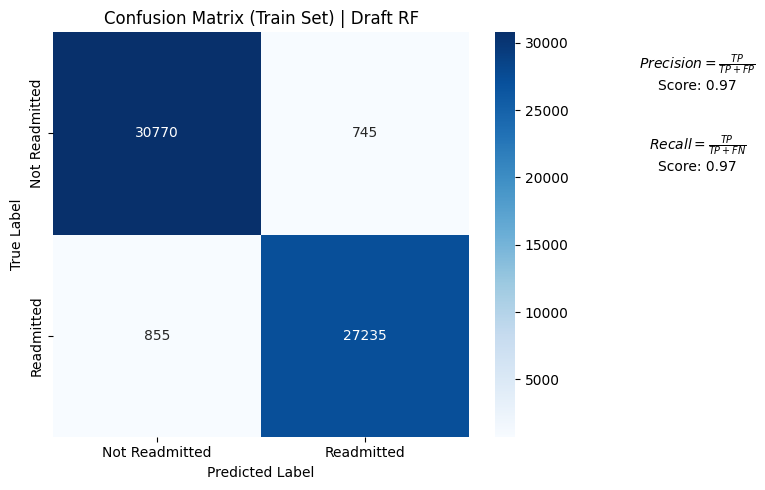

{'precision': 0.97337383845604,
 'recall': 0.969562121751513,
 'confusion_matrix': array([[30770,   745],
        [  855, 27235]])}

In [29]:
recall_tr, precision_tr, f1_tr, cl_report_tr = \
    evaluate_predictions(true_values=df_ytrain,
                         predictions=y_pred_tr,
                         print_class_report=True)

plot_confusion_matrix(df_ytrain['readmitted'],
                      y_pred_tr,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5),
                      title='Confusion Matrix (Train Set) | Draft RF')

### Initial Classification Report: Validation Set

              precision    recall  f1-score   support

           0       0.60      0.62      0.61     10506
           1       0.56      0.54      0.55      9363

    accuracy                           0.58     19869
   macro avg       0.58      0.58      0.58     19869
weighted avg       0.58      0.58      0.58     19869



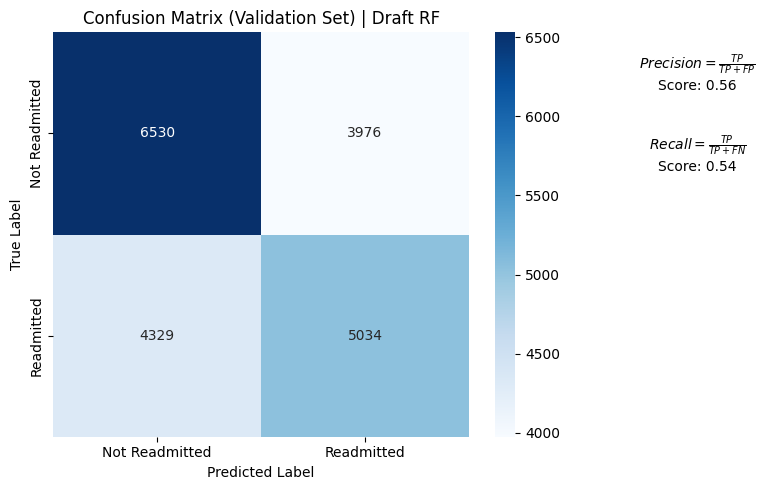

{'precision': 0.5587125416204217,
 'recall': 0.5376481896827939,
 'confusion_matrix': array([[6530, 3976],
        [4329, 5034]])}

In [30]:
recall_vl, precision_vl, f1_vl, cl_report_vl = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)

plot_confusion_matrix(df_yval['readmitted'],
                      y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5),
                      title='Confusion Matrix (Validation Set) | Draft RF')

## Full Feature Model

Using all one-hot encoded features:

---> Training set Evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31515
           1       1.00      1.00      1.00     28090

    accuracy                           1.00     59605
   macro avg       1.00      1.00      1.00     59605
weighted avg       1.00      1.00      1.00     59605



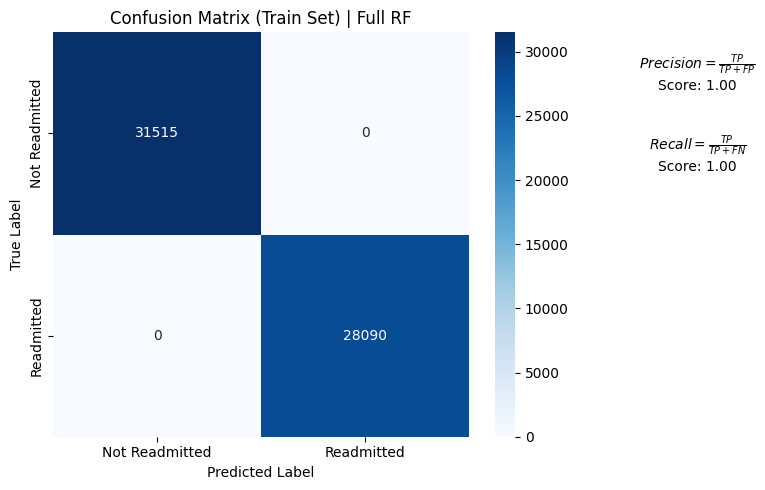

---> Validation set Evaluation

              precision    recall  f1-score   support

           0       0.63      0.73      0.67     10506
           1       0.63      0.52      0.57      9363

    accuracy                           0.63     19869
   macro avg       0.63      0.62      0.62     19869
weighted avg       0.63      0.63      0.62     19869



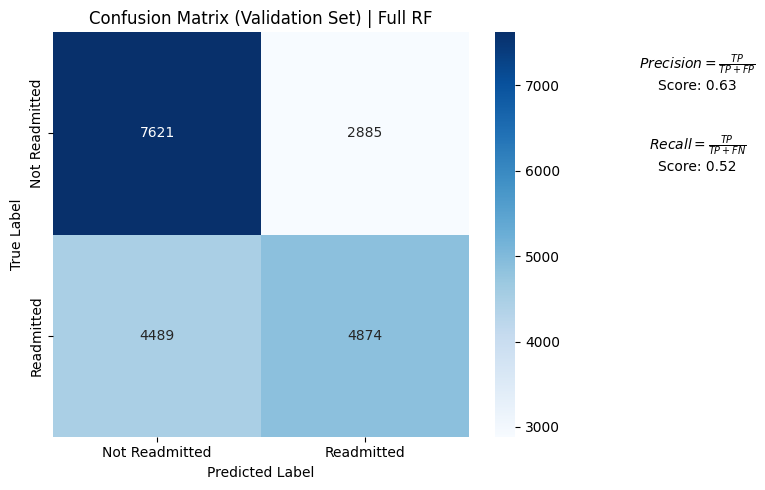

{'precision': 0.6281737337285733,
 'recall': 0.5205596496849301,
 'confusion_matrix': array([[7621, 2885],
        [4489, 4874]])}

In [31]:
rf_full, y_pred_tr, y_pred_vl = fit_random_forest(
    Xtrain=X_train_rf,
    ytrain=df_ytrain,
    Xval=X_val_rf,
    chosen_features_list=None,  # use all features
    seed=SEED
)

print('---> Training set Evaluation\n')
recall_tr, precision_tr, f1_tr, _ = \
    evaluate_predictions(true_values=df_ytrain,
                         predictions=y_pred_tr,
                         print_class_report=True)
plot_confusion_matrix(df_ytrain['readmitted'], y_pred_tr,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), title='Confusion Matrix (Train Set) | Full RF')

print('---> Validation set Evaluation\n')
recall_vl, precision_vl, f1_vl, _ = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)
plot_confusion_matrix(df_yval['readmitted'], y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), title='Confusion Matrix (Validation Set) | Full RF')

### Feature Importance

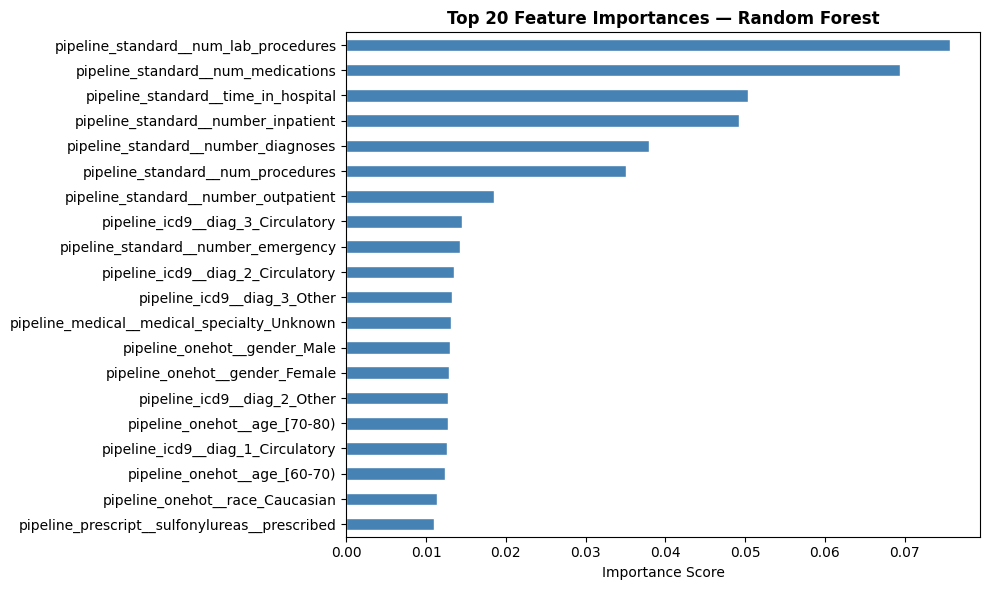

In [32]:
# Top 20 most important features
importances = pd.Series(rf_full.feature_importances_,
                        index=X_train_rf.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Part 3 - Hyperparameter Tuning with Optuna

In [33]:
def objective(trial,
              X_train=X_train_rf,
              X_val=X_val_rf,
              ytrain=df_ytrain,
              yval=df_yval):

    n_estimators     = trial.suggest_int('n_estimators', 50, 500)
    max_depth        = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10)

    _, _, y_pred_vl = fit_random_forest(
        Xtrain=X_train,
        ytrain=ytrain,
        Xval=X_val,
        seed=SEED,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf
    )

    recall_vl, _, _, _ = evaluate_predictions(
        true_values=yval,
        predictions=y_pred_vl,
        print_class_report=False
    )
    return recall_vl

In [34]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,
               #originally 50 trials, but I set to 5 for now
               n_trials=5,
               timeout=600,
               n_jobs=-1)

[I 2026-07-10 01:12:35,529] A new study created in memory with name: no-name-862f99cf-80fd-4f4a-a578-20d55cf9c7da
[I 2026-07-10 01:13:00,307] Trial 1 finished with value: 0.5586884545551639 and parameters: {'n_estimators': 234, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.5586884545551639.
[I 2026-07-10 01:13:38,852] Trial 0 finished with value: 0.5703300224287088 and parameters: {'n_estimators': 446, 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.5703300224287088.
[I 2026-07-10 01:13:53,470] Trial 3 finished with value: 0.5536686959307914 and parameters: {'n_estimators': 298, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.5703300224287088.
[I 2026-07-10 01:14:17,730] Trial 2 finished with value: 0.5863505286767062 and parameters: {'n_estimators': 385, 'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 8}. Best is trial 2 with valu

KeyboardInterrupt: 

In [ ]:
print(study.best_trial)

In [36]:
best_params = study.best_params
print(f'Best params: {best_params}')

Best params: {'n_estimators': 385, 'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 8}


### Part 4 - Re-train with Best Hyperparameters & Evaluate on Test Set

In [ ]:
best_rf, y_pred_tr, y_pred_vl = fit_random_forest(
    Xtrain=X_train_rf,
    ytrain=df_ytrain,
    Xval=X_val_rf,
    seed=SEED,
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)

print('Validation set evaluation:')
recall_vl, precision_vl, f1_vl, _ = \
    evaluate_predictions(true_values=df_yval,
                         predictions=y_pred_vl,
                         print_class_report=True)
plot_confusion_matrix(df_yval['readmitted'], y_pred_vl,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), colour_map='Reds',
                      title='Confusion Matrix (Validation Set) | Best RF Params')

[I 2026-07-10 01:16:05,462] Trial 6 finished with value: 0.5737477304282815 and parameters: {'n_estimators': 449, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.5863505286767062.


In [ ]:
from optuna.visualization import plot_slice
plot_slice(study)

#### Test Set (Unseen Data) Evaluation

In [ ]:
y_pred_ts = best_rf.predict(X_test_rf)

print('Test set evaluation:')
recall_ts, precision_ts, f1_ts, _ = \
    evaluate_predictions(true_values=df_ytest,
                         predictions=y_pred_ts,
                         print_class_report=True)

plot_confusion_matrix(df_ytest['readmitted'], y_pred_ts,
                      class_names=['Not Readmitted', 'Readmitted'],
                      fig_size=(8, 5), colour_map='Greens',
                      title=f'Confusion Matrix (Test Set) | Best RF')

# AUC-ROC
y_proba_ts = best_rf.predict_proba(X_test_rf)[:, 1]
auc = roc_auc_score(df_ytest['readmitted'], y_proba_ts)
print(f'\nAUC-ROC (Test Set): {auc:.4f}')